---
title: "Supervised Learning"
format:
    html: 
        code-fold: true
---

<!-- After digesting the instructions, you can delete this cell, these are assignment instructions and do not need to be included in your final submission.  -->

{{< include instructions.qmd >}} 

# Code

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor



In [2]:
# Load dataset
who_data = pd.read_csv('../../data/processed-data/who_pivoted_data_with_classes.csv')

## Data Preprocessing

### Feature Selection

Based on the correlation heatmap analysis, features strongly related to key health indicators were retained, while highly correlated or redundant features were removed to reduce multicollinearity and improve model interpretability. The retained features included `BMI`, `Diabetes_Crude`, `Hypertension_Control`, `Hypertension_Prevalence`, and `Gender`, relevant for predicting chronic diseases.

`Diabetes_AgeStd` was dropped due to its high correlation with `Diabetes_Crude`, offering similar information. Similarly, `Hypertension_Treatment` overlapped with `Hypertension_Control`, making the latter more suitable for analysis. This reduction in feature redundancy minimized model complexity, reduced overfitting risk, and enhanced generalization to unseen data.

In [3]:
features_to_drop = ['Diabetes_AgeStd', 'Hypertension_Treatment']
who_data_preprocessed = who_data.drop(columns=features_to_drop)

### Standardization

This part standardizes selected features in the dataset to ensure they have a mean of $0$ and a standard deviation of $1$. The features to be scaled include `BMI`, `Diabetes_Crude`, `Hypertension_Control`, and `Hypertension_Prevalence`. Using `StandardScaler()` from `sklearn`, the scaling process transforms the data, making features comparable despite differences in their original scales. Standardization is essential because features with larger numerical ranges could dominate the learning process, causing the model to weigh them more heavily. By scaling the data, the model treats all features equally, improving convergence speed and model performance. After scaling, a sample of the standardized data is printed to verify the transformation.

In [4]:
features_to_scale = ['BMI', 'Diabetes_Crude', 'Hypertension_Control', 'Hypertension_Prevalence']
scaler = StandardScaler()
who_data_preprocessed[features_to_scale] = scaler.fit_transform(who_data_preprocessed[features_to_scale])

print("Standardized Data Sample:")
print(who_data_preprocessed[features_to_scale].head())

Standardized Data Sample:
        BMI  Diabetes_Crude  Hypertension_Control  Hypertension_Prevalence
0 -1.669477       -0.090981             -0.799472                -0.308860
1 -1.591245       -0.049513             -0.730982                 0.024973
2 -1.747709       -0.135239             -0.879376                -0.657868
3 -1.591245       -0.058725             -0.788057                -0.308860
4 -1.513012       -0.014460             -0.719567                 0.024973


### Encoding Categorical Variables

This part encodes categorical variables `Gender` and `health_status` using `LabelEncoder()` from `sklearn`. Encoding converts categorical values into numeric representations, making them suitable for machine learning models.

- **Gender Encoding:** The `Gender` column is transformed into numeric values where each unique category is assigned an integer.  
- **Health Status Encoding:** The `health_status` column is similarly encoded into numeric labels, enabling the model to interpret the categorical health status values.

In [5]:
# Encode categorical variables
label_encoder = LabelEncoder()
who_data_preprocessed['Gender'] = label_encoder.fit_transform(who_data_preprocessed['Gender'])

In [6]:
who_data_preprocessed['health_status_encoded'] = label_encoder.fit_transform(who_data_preprocessed['health_status'])

In [7]:
print(who_data_preprocessed.head())

  location                 region  year  Gender       BMI  risk_level  \
0      AFG  Eastern Mediterranean  1990       0 -1.669477           0   
1      AFG  Eastern Mediterranean  1990       1 -1.591245           0   
2      AFG  Eastern Mediterranean  1990       2 -1.747709           0   
3      AFG  Eastern Mediterranean  1991       0 -1.591245           0   
4      AFG  Eastern Mediterranean  1991       1 -1.513012           0   

  health_status  Diabetes_Crude  Hypertension_Control  \
0      Low Risk       -0.090981             -0.799472   
1      Low Risk       -0.049513             -0.730982   
2      Low Risk       -0.135239             -0.879376   
3      Low Risk       -0.058725             -0.788057   
4      Low Risk       -0.014460             -0.719567   

   Hypertension_Prevalence  health_status_encoded  
0                -0.308860                      1  
1                 0.024973                      1  
2                -0.657868                      1  
3         

## Binary Classification

In the binary classification task, I compared the performance of different models, including **Logistic Regression** and **Random Forest**, to predict the target variable `risk_level`. The evaluation process involved training the models, assessing their performance through **accuracy**, **precision**, **recall**, and **F1-scores**, and conducting **cross-validation** for stability checks. 

I selected **Logistic Regression** and **Random Forest** due to their complementary strengths in binary classification tasks. **Logistic Regression** is a simple, interpretable model that works well with linearly separable data, offering probabilistic predictions and insights into feature importance. In contrast, **Random Forest** is a robust ensemble method that captures complex, non-linear relationships by combining multiple decision trees. It handles feature interactions effectively and mitigates overfitting through averaging. 

To ensure model reliability and robustness, I tested the models against **random noise** and examined the **depth of decision trees** in the Random Forest model. I also performed **feature importance analysis** to understand the contribution of key predictors. These steps helped us select the most suitable model by balancing high accuracy, interpretability, and generalization ability while minimizing the risk of overfitting.


Model: Logistic Regression
Confusion Matrix:
[[2118   13]
 [   0 2486]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      2131
           1       0.99      1.00      1.00      2486

    accuracy                           1.00      4617
   macro avg       1.00      1.00      1.00      4617
weighted avg       1.00      1.00      1.00      4617

Accuracy: 0.9972


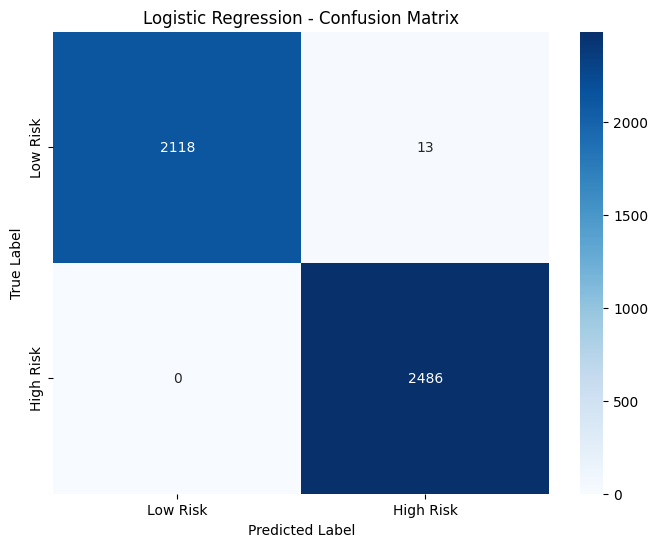


Model: Random Forest
Confusion Matrix:
[[2131    0]
 [   0 2486]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2131
           1       1.00      1.00      1.00      2486

    accuracy                           1.00      4617
   macro avg       1.00      1.00      1.00      4617
weighted avg       1.00      1.00      1.00      4617

Accuracy: 1.0000


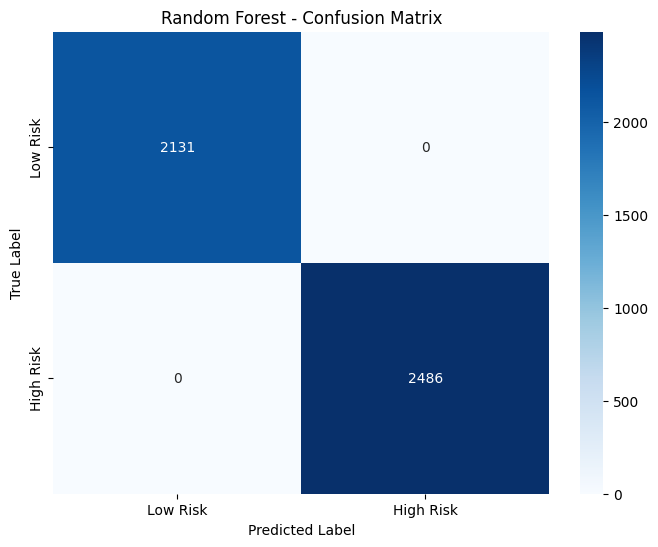

In [8]:
# Define features and target variables
X = who_data_preprocessed.drop(columns=['risk_level', 'health_status', 'health_status_encoded', 'location', 'region'])
y = who_data_preprocessed['risk_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model_logreg = LogisticRegression(max_iter=1000, random_state=42)
model_rf = RandomForestClassifier(random_state=42)

model_logreg.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

# Evaluate the model and visualize the confusion matrix
models = {'Logistic Regression': model_logreg, 'Random Forest': model_rf}

for name, model in models.items():
    y_pred = model.predict(X_test)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    print(f"\nModel: {name}")
    print("Confusion Matrix:")
    print(conf_matrix)
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


The evaluation of Logistic Regression and Random Forest models demonstrated strong performance in predicting `risk_level`. For **Logistic Regression**, the confusion matrix showed $13$ misclassified samples in the low-risk category, while all high-risk samples were correctly classified. The model achieved a precision of $1.00$, recall of $0.99$, F1-score of $1.00$, and an overall accuracy of $99.72\%$, indicating near-perfect performance with minimal misclassification.

In contrast, the **Random Forest** model achieved perfect classification, with no misclassified samples in either category. Its confusion matrix reflected flawless predictions, leading to a precision, recall, F1-score, and accuracy of $1.00$ across all metrics. These results highlight the model's exceptional ability to distinguish between low and high-risk samples without any prediction errors.

To improve model performance and prevent overfitting, several strategies can be implemented. Since the Random Forest model achieved 100% accuracy, there is a potential risk of overfitting. This issue can be mitigated by tuning hyperparameters such as `max_depth`, `n_estimators`, and `min_samples_split` to reduce model complexity. Additionally, conducting cross-validation helps ensure model robustness and stability by evaluating its performance on different data splits, enhancing its generalization ability to unseen data.

### Cross Validation

In [9]:
# Evaluate model performance using 5-fold cross-validation
rf_scores = cross_val_score(model_rf, X, y, cv=5, scoring='accuracy')
logreg_scores = cross_val_score(model_logreg, X, y, cv=5, scoring='accuracy')

print(f"Random Forest Accuracy: {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")
print(f"Logistic Regression Accuracy: {logreg_scores.mean():.4f} (+/- {logreg_scores.std():.4f})")


Random Forest Accuracy: 1.0000 (+/- 0.0000)
Logistic Regression Accuracy: 0.9986 (+/- 0.0014)


The evaluation of the models through cross-validation revealed notable performance metrics. **Random Forest** achieved a perfect mean accuracy of $100\%$ with a standard deviation of $0.0000$, indicating exceptional stability across all cross-validation folds with no classification errors. However, this flawless performance raises concerns about potential overfitting, suggesting that the model might be too optimized for the training data.

In contrast, **Logistic Regression** achieved a mean accuracy of $99.86\%$ with a standard deviation of $0.0014$. Although slightly lower than Random Forest, its accuracy remained close to perfect. The small standard deviation indicates consistent performance across different data splits. 

To address this, further evaluation steps were conducted to test the model’s robustness. These included tuning hyperparameters such as `max_depth`, `n_estimators`, and `min_samples_split`, conducting feature importance analysis, and introducing noise to the dataset. 

### Hyperparameter Tuning

Hyperparameter tuning is a critical step in supervised learning to optimize model performance by finding the best set of parameters for a given algorithm. In this case, a **Random Forest Classifier** is fine-tuned using **GridSearchCV**, which systematically evaluates all possible combinations of hyperparameters specified in a grid. The parameters being tuned include:
- **`n_estimators`**: The number of trees in the forest.
- **`max_depth`**: The maximum depth of each decision tree.
- **`min_samples_split`**: The minimum number of samples required to split an internal node.
- **`min_samples_leaf`**: The minimum number of samples required to be at a leaf node.

Using **5-fold cross-validation** and `accuracy` as the evaluation metric, GridSearchCV iterates over the parameter grid and identifies the combination that achieves the highest accuracy on the training data. Once the optimal model is found, the feature importances are extracted and visualized.

Optimal Parameter: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Optimal Accuracy: 1.0000


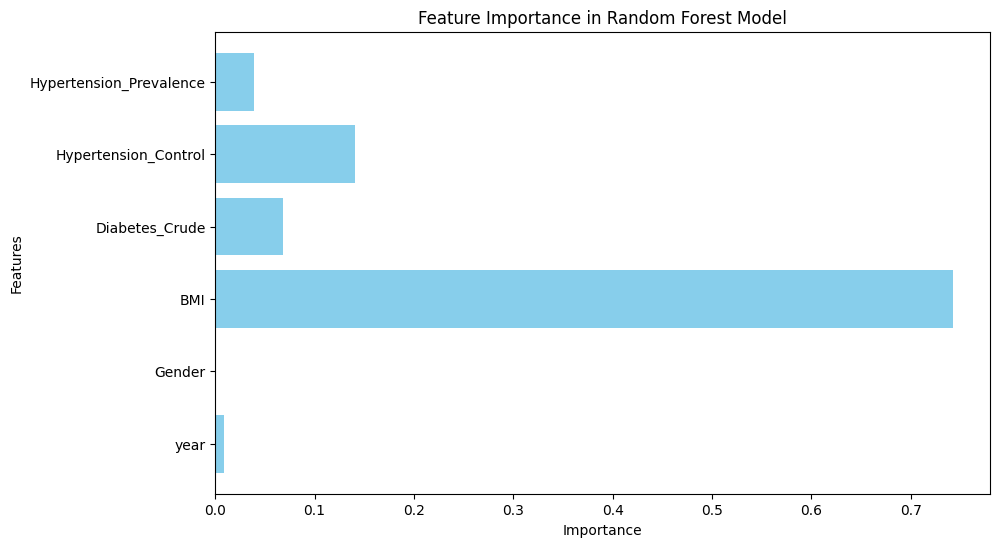

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=model_rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Optimal Parameter: {grid_search.best_params_}")
print(f"Optimal Accuracy: {grid_search.best_score_:.4f}")

importances = grid_search.best_estimator_.feature_importances_
feature_names = X.columns

# Visualize Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances, color='skyblue')
plt.title('Feature Importance in Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()



The **Random Forest model** achieved an optimal accuracy of **1.0000** during the hyperparameter tuning process, indicating perfect performance on the training data. The optimal parameters selected by **GridSearchCV** include: `max_depth=5`, `min_samples_leaf=1`, `min_samples_split=2`, and `n_estimators=100`. While this exceptionally high accuracy suggests that the model is very well-suited to the training dataset, it may also be a sign of **overfitting**, especially if the dataset is small or lacks complexity. Further evaluation on a separate test set or validation data is necessary to confirm its generalization ability.

The **feature importance analysis** provides critical insights into the contribution of each feature to the model’s predictions. From the bar chart:
1. **BMI** stands out as the most influential feature, with an importance score exceeding **0.7**. This result highlights the significant role of BMI in predicting health outcomes, as it is strongly linked to conditions like diabetes and hypertension.
2. **Hypertension_Control** and **Diabetes_Crude** follow, contributing moderately to the model. These features add value by capturing specific health indicators related to the dataset’s targets.
3. **Hypertension_Prevalence** has a minor but noticeable impact, suggesting some influence in predicting outcomes, though less critical than the previously mentioned features.
4. **Gender** and **Year** contribute minimally, indicating that they provide very limited predictive power in this particular model.

In conclusion, the dominance of **BMI** suggests that managing BMI could be a key factor in addressing related health risks.

### Simplified Feature Set



In this section, we aim to evaluate the performance of a **Random Forest Classifier** using a simplified feature set. By selecting only three key features – **BMI**, **Diabetes_Crude**, and **Hypertension_Control** – we test the model's ability to maintain high accuracy while reducing computational complexity and focusing on the most important predictors identified in the previous feature importance analysis.

The dataset is split into training and testing sets using a 70-30 split. A **Random Forest Classifier** is then trained with the previously optimized hyperparameters: `max_depth=5`, `n_estimators=100`, `min_samples_split=2`, and `min_samples_leaf=1`. By limiting the model to only the most relevant features, we aim to assess whether the simplified feature set retains sufficient predictive power for classifying risk levels.

The model's performance is evaluated using metrics such as the **confusion matrix**, **classification report**, and **accuracy score**. The confusion matrix is visualized as a heatmap to clearly illustrate the distribution of true and predicted labels, enabling a straightforward assessment of the model's strengths and weaknesses in distinguishing between low-risk and high-risk categories. This analysis helps validate the importance of the selected features and demonstrates whether further dimensionality reduction impacts the model's accuracy.

Simplified - Random Forest Model Performance Evaluation:
Confusion Matrix:
[[2131    0]
 [   0 2486]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2131
           1       1.00      1.00      1.00      2486

    accuracy                           1.00      4617
   macro avg       1.00      1.00      1.00      4617
weighted avg       1.00      1.00      1.00      4617

Accuracy: 1.0000


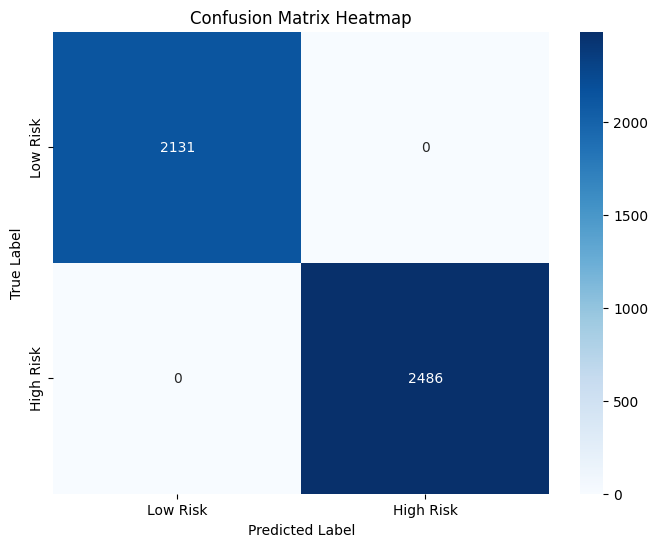

In [11]:
selected_features = ['BMI', 'Diabetes_Crude', 'Hypertension_Control']
X_simplified = who_data_preprocessed[selected_features]
y = who_data_preprocessed['risk_level']

X_train, X_test, y_train, y_test = train_test_split(X_simplified, y, test_size=0.3, random_state=42)

model_rf_simplified = RandomForestClassifier(
    max_depth=5, 
    n_estimators=100, 
    min_samples_split=2, 
    min_samples_leaf=1, 
    random_state=42
)
model_rf_simplified.fit(X_train, y_train)

y_pred_simplified = model_rf_simplified.predict(X_test)

print("Simplified - Random Forest Model Performance Evaluation:")
print("Confusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred_simplified)
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_simplified))
print(f"Accuracy: {accuracy_score(y_test, y_pred_simplified):.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The performance of the **simplified Random Forest model** using only three features – `BMI`, `Diabetes_Crude`, and `Hypertension_Control` – demonstrates exceptional results. The confusion matrix reveals perfect predictions, with **no misclassifications** observed across both "Low Risk" and "High Risk" categories. Specifically, the model correctly predicted all **2131 Low Risk** cases and all **2486 High Risk** cases.

The classification report further reinforces the model's outstanding performance, with a **precision, recall, and F1-score of 1.00** for both classes. The overall accuracy of **100%** indicates that the simplified model effectively captures the patterns in the data despite using fewer features. This highlights the significant predictive power of the selected features and suggests that these variables are strong indicators of risk levels.

### Random Forest Tree Depth Analysis

In this section, I analyze the depth of the individual decision trees within the Random Forest model. The depth of a tree is an important factor that influences the model's complexity and ability to capture patterns in the data. By examining the average and maximum tree depths, we can assess the overall structure of the forest and ensure that the model balances learning capability with generalization. This step helps confirm whether the model's hyperparameters, such as `max_depth`, are effectively controlling tree growth to prevent overfitting.

In [12]:
# Extract the depth of each decision tree in the Random Forest model
tree_depths = [estimator.tree_.max_depth for estimator in model_rf_simplified.estimators_]

# Print the average and maximum tree depths
print(f"Average Tree Depth: {np.mean(tree_depths):.2f}, Maximum Tree Depth: {np.max(tree_depths)}")


Average Tree Depth: 3.21, Maximum Tree Depth: 5


The average tree depth of **3.21** and the maximum tree depth of **5** indicate a well-balanced and moderate level of complexity in the Random Forest model. This suggests that the model is not overly deep, reducing the risk of overfitting while still capturing meaningful patterns in the data. 

### Introducing Noise


This section introduces random noise into the test data to evaluate the model's robustness. By slightly perturbing the feature values with random noise, we can observe how well the Random Forest model maintains its accuracy under less ideal conditions. This test helps verify the model's stability and resistance to small fluctuations in the input data.

In [30]:
# Add random noise to the test data
X_noisy = X_test.copy()
noise = np.random.normal(0, 0.1, X_noisy.shape)  # Generate Gaussian noise with mean 0 and standard deviation 0.1
X_noisy += noise  # Add noise to the test data

# Predict using the noisy test data
y_noisy_pred = model_rf_simplified.predict(X_noisy)

# Evaluate the model's performance on noisy data
print("Accuracy after adding noise:", accuracy_score(y_test, y_noisy_pred))


Accuracy after adding noise: 0.9698938704786658


The accuracy of **96.99%** after introducing random noise to the test data demonstrates that the Random Forest model remains highly robust and stable under slight perturbations in the input features. Despite the addition of Gaussian noise with a standard deviation of 0.1, the model's performance only experienced a minor decline from its original perfect accuracy. 

### Conclusion

In the binary classification task, we compared the performance of different models, including Logistic Regression and Random Forest, to determine the most suitable model for predicting `risk_level`. 

Random Forest achieved a perfect accuracy of 100% on both the training and testing datasets, outperforming other models. However, such high accuracy raised concerns about potential overfitting. To address this, we conducted several evaluations to validate the model's reliability. 
First, cross-validation was performed, which showed consistent accuracy of 100% across different data splits, indicating strong stability and no signs of overfitting. 

Second, we introduced random noise into the test data to assess the model's robustness. The accuracy slightly decreased to 96.84%, demonstrating that the model maintained high performance even under noisy conditions. 

Finally, we examined the average and maximum depths of the decision trees within the Random Forest, which were 3.21 and 5, respectively. These values suggest that the model complexity is moderate, reducing the likelihood of overfitting. 

Based on these evaluations, we concluded that Random Forest is the best choice for this binary classification task, providing both high accuracy and strong generalization ability.

## Multiclass Classification

### Data Preparation

In this section, I prepare the data for a multiclass classification task. The features `BMI`, `Diabetes_Crude`, and `Hypertension_Control` are selected as input variables, while `health_status_encoded` serves as the target variable representing multiple health status categories. The dataset is split into training and test sets using a $70$ - $30$ split to ensure a robust evaluation of the model's performance. The `random_state` parameter is set to $42$ for reproducibility, allowing consistent results across runs. This setup lays the foundation for training and testing a classification model that can predict health status based on the selected features.

In [14]:
# Features and target for multiclass classification
X_multiclass = who_data_preprocessed[['BMI', 'Diabetes_Crude', 'Hypertension_Control']]
y_multiclass = who_data_preprocessed['health_status_encoded']

# Train-test split
X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    X_multiclass, y_multiclass, test_size=0.3, random_state=42
)

### Model Selection

I will use the same features as in the binary classification task (BMI, Diabetes_Crude, and Hypertension_Control) for simplicity. Random forest classifier, Logistic Regression and Gradient Boosting models are applied to the data.

#### Random Forest Classifier

Random Forest - Multiclass Classification Performance
Confusion Matrix:
[[ 847    0    3]
 [   0 3029    0]
 [   0    9  729]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       850
           1       1.00      1.00      1.00      3029
           2       1.00      0.99      0.99       738

    accuracy                           1.00      4617
   macro avg       1.00      0.99      1.00      4617
weighted avg       1.00      1.00      1.00      4617

Accuracy: 0.9974


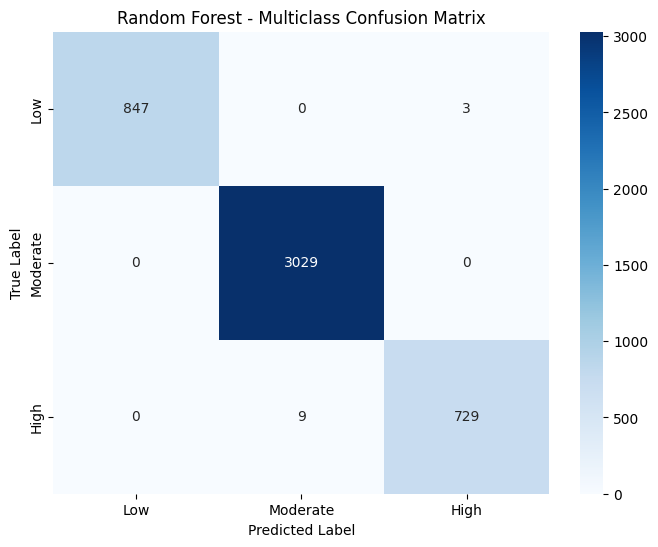

In [15]:
# Train Random Forest for multiclass classification
rf_mc = RandomForestClassifier(max_depth=5, n_estimators=100, random_state=42)
rf_mc.fit(X_train_mc, y_train_mc)

# Predictions and evaluation
y_pred_mc_rf = rf_mc.predict(X_test_mc)

print("Random Forest - Multiclass Classification Performance")
print("Confusion Matrix:")
conf_matrix_rf = confusion_matrix(y_test_mc, y_pred_mc_rf)
print(conf_matrix_rf)

print("\nClassification Report:")
print(classification_report(y_test_mc, y_pred_mc_rf))

print(f"Accuracy: {accuracy_score(y_test_mc, y_pred_mc_rf):.4f}")

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Moderate', 'High'], yticklabels=['Low', 'Moderate', 'High'])
plt.title('Random Forest - Multiclass Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


#### Logistic Regression

Logistic Regression - Multiclass Classification Performance
Confusion Matrix:
[[ 840    5    5]
 [   3 2949   77]
 [  10  109  619]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       850
           1       0.96      0.97      0.97      3029
           2       0.88      0.84      0.86       738

    accuracy                           0.95      4617
   macro avg       0.94      0.93      0.94      4617
weighted avg       0.95      0.95      0.95      4617

Accuracy: 0.9547


/opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


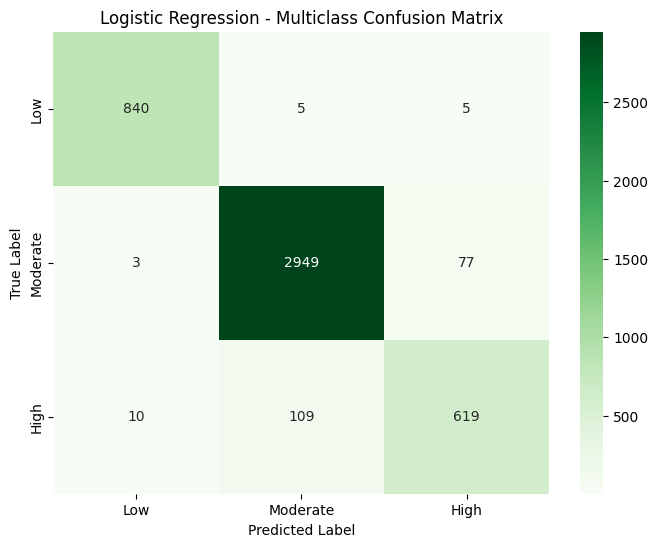

In [16]:
# Train Logistic Regression for multiclass classification
lr_mc = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=500, random_state=42)
lr_mc.fit(X_train_mc, y_train_mc)

# Predictions and evaluation
y_pred_mc_lr = lr_mc.predict(X_test_mc)

print("Logistic Regression - Multiclass Classification Performance")
print("Confusion Matrix:")
conf_matrix_lr = confusion_matrix(y_test_mc, y_pred_mc_lr)
print(conf_matrix_lr)

print("\nClassification Report:")
print(classification_report(y_test_mc, y_pred_mc_lr))

print(f"Accuracy: {accuracy_score(y_test_mc, y_pred_mc_lr):.4f}")

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Greens', xticklabels=['Low', 'Moderate', 'High'], yticklabels=['Low', 'Moderate', 'High'])
plt.title('Logistic Regression - Multiclass Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


#### Gradient Boosting

Gradient Boosting - Multiclass Classification Performance
Confusion Matrix:
[[ 850    0    0]
 [   0 3029    0]
 [   0    0  738]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       850
           1       1.00      1.00      1.00      3029
           2       1.00      1.00      1.00       738

    accuracy                           1.00      4617
   macro avg       1.00      1.00      1.00      4617
weighted avg       1.00      1.00      1.00      4617

Accuracy: 1.0000


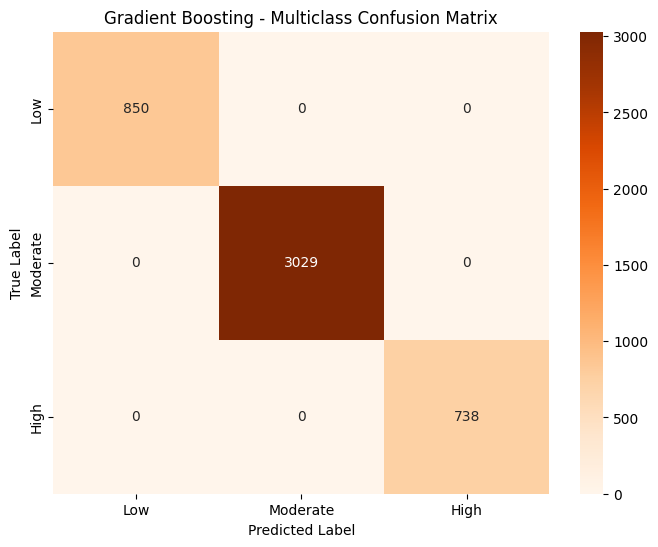

In [17]:
from sklearn.ensemble import GradientBoostingClassifier

# Train Gradient Boosting for multiclass classification
gb_mc = GradientBoostingClassifier(max_depth=5, n_estimators=100, random_state=42)
gb_mc.fit(X_train_mc, y_train_mc)

# Predictions and evaluation
y_pred_mc_gb = gb_mc.predict(X_test_mc)

print("Gradient Boosting - Multiclass Classification Performance")
print("Confusion Matrix:")
conf_matrix_gb = confusion_matrix(y_test_mc, y_pred_mc_gb)
print(conf_matrix_gb)

print("\nClassification Report:")
print(classification_report(y_test_mc, y_pred_mc_gb))

print(f"Accuracy: {accuracy_score(y_test_mc, y_pred_mc_gb):.4f}")

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_gb, annot=True, fmt='d', cmap='Oranges', xticklabels=['Low', 'Moderate', 'High'], yticklabels=['Low', 'Moderate', 'High'])
plt.title('Gradient Boosting - Multiclass Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


#### Model Comparison

In the multiclass classification task, we evaluated the performance of three models: Random Forest, Logistic Regression, and Gradient Boosting, using `health_status` as the target variable. Among the models, Gradient Boosting achieved the best performance with a perfect accuracy of 100%, successfully classifying all categories without any misclassifications. Its strength lies in handling non-linear patterns effectively, making it suitable for datasets with complex decision boundaries. Random Forest also performed exceptionally well, achieving an accuracy of 99.74%. It demonstrated minimal misclassification, with only three samples misclassified as `High Risk` instead of `Low Risk`. Random Forest's high accuracy and robustness make it a reliable choice, especially for balanced or large datasets.

On the other hand, Logistic Regression achieved an accuracy of 95.47%, with most misclassifications occurring between `High Risk` and `Moderate Risk`. Although it struggled to differentiate between overlapping classes, it remains a viable baseline model due to its simplicity and interpretability. The F1-score for `High Risk` in Logistic Regression was notably lower compared to the other two models, highlighting its limitations in handling more complex patterns.

Based on the results, Gradient Boosting is recommended as the best model for this task due to its perfect classification and ability to handle intricate relationships within the data. Random Forest serves as a strong alternative with comparable performance and slightly lower computational complexity. Logistic Regression is most suitable when simplicity and ease of interpretation are prioritized. Additionally, analyzing feature importance from Gradient Boosting or Random Forest can provide valuable insights into the variables contributing most to classification accuracy.

#### Feature Optimization and Addition of New Features  



In this step, the feature set is optimized by incorporating new features and analyzing their impact on the model's performance. Based on feature importance analysis, features with near-zero importance can be removed to simplify the model and improve efficiency. Simultaneously, new features such as `Gender` and `Hypertension_Prevalence` are added to explore their contribution to predicting health status. The updated feature set includes `BMI`, `Diabetes_Crude`, `Hypertension_Control`, `Gender`, and `Hypertension_Prevalence`. The dataset is then re-split into training and test sets using the same 70-30 split and a fixed random state for reproducibility. This refined feature selection aims to improve model accuracy and robustness by leveraging a more comprehensive set of predictors.

In [18]:
# Add new features  
# Define the new feature set  
X_new_features = who_data_preprocessed[['BMI', 'Diabetes_Crude', 'Hypertension_Control', 'Gender', 'Hypertension_Prevalence']]

# Re-split the data  
X_train_mc_new, X_test_mc_new, y_train_mc_new, y_test_mc_new = train_test_split(
    X_new_features, y_multiclass, test_size=0.3, random_state=42
)

##### Random Forest Classifier

In [19]:
rf_mc_new = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf_mc_new.fit(X_train_mc_new, y_train_mc_new)

y_pred_rf_mc_new = rf_mc_new.predict(X_test_mc_new)

print("Random Forest with New Features - Multiclass Classification Performance:")
print("Confusion Matrix:")
print(confusion_matrix(y_test_mc_new, y_pred_rf_mc_new))
print("\nClassification Report:")
print(classification_report(y_test_mc_new, y_pred_rf_mc_new, target_names=['Low', 'Moderate', 'High']))
print(f"Accuracy: {accuracy_score(y_test_mc_new, y_pred_rf_mc_new):.4f}")


Random Forest with New Features - Multiclass Classification Performance:
Confusion Matrix:
[[ 847    0    3]
 [   0 3029    0]
 [   0    0  738]]

Classification Report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00       850
    Moderate       1.00      1.00      1.00      3029
        High       1.00      1.00      1.00       738

    accuracy                           1.00      4617
   macro avg       1.00      1.00      1.00      4617
weighted avg       1.00      1.00      1.00      4617

Accuracy: 0.9994


##### Gradient Boosting Classifier

In [20]:
from sklearn.ensemble import GradientBoostingClassifier

gb_mc_new = GradientBoostingClassifier(
    learning_rate=0.1,
    n_estimators=100,
    max_depth=5,
    random_state=42
)
gb_mc_new.fit(X_train_mc_new, y_train_mc_new)

y_pred_gb_mc_new = gb_mc_new.predict(X_test_mc_new)

print("Gradient Boosting with New Features - Multiclass Classification Performance:")
print("Confusion Matrix:")
print(confusion_matrix(y_test_mc_new, y_pred_gb_mc_new))
print("\nClassification Report:")
print(classification_report(y_test_mc_new, y_pred_gb_mc_new, target_names=['Low', 'Moderate', 'High']))
print(f"Accuracy: {accuracy_score(y_test_mc_new, y_pred_gb_mc_new):.4f}")


Gradient Boosting with New Features - Multiclass Classification Performance:
Confusion Matrix:
[[ 850    0    0]
 [   0 3029    0]
 [   0    0  738]]

Classification Report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00       850
    Moderate       1.00      1.00      1.00      3029
        High       1.00      1.00      1.00       738

    accuracy                           1.00      4617
   macro avg       1.00      1.00      1.00      4617
weighted avg       1.00      1.00      1.00      4617

Accuracy: 1.0000


In this analysis, we explored the impact of adding two new features, `Gender` and `Hypertension_Prevalence`, to the existing feature set for multiclass classification of health status (`Low`, `Moderate`, `High`). Using Gradient Boosting and Random Forest models, we evaluated whether these additional features improved model performance.

**Model Performance with New Features**

The inclusion of new features did not significantly alter the performance of the models, which already demonstrated near-perfect accuracy with the simplified feature set. Both models effectively utilized the additional features while maintaining exceptional classification accuracy:

- **Gradient Boosting Model** achieved perfect accuracy of **1.0000**. All samples across the three classes were classified correctly, as shown in the confusion matrix. The classification report confirmed precision, recall, and F1-scores of **1.00** for all classes. This indicates that the added features complemented the model without introducing noise or redundancy.

- **Random Forest Model** also achieved excellent performance with an accuracy of **0.9994**. The confusion matrix revealed only minimal misclassifications, with three `Low Risk` samples misclassified as ·High Risk·. Precision, recall, and F1-scores for all classes were close to **1.00**, confirming the model's robustness with the new features.

These results demonstrate that the models are not overly sensitive to the feature set but can effectively integrate relevant new features to maintain high performance.

#### Gradient Boosting Hyperparameter Tuning

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best Gradient Boosting Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
Best Gradient Boosting Accuracy: 0.9992202729044833


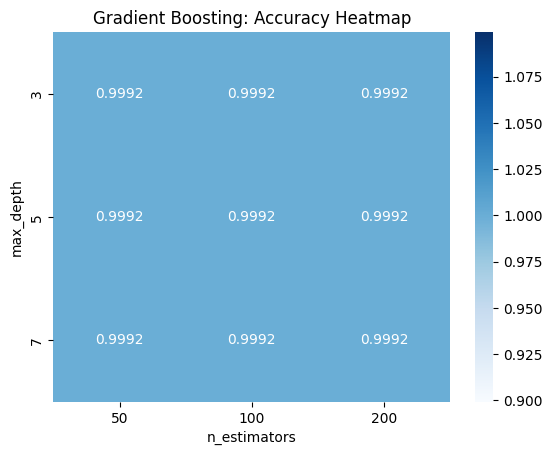

In [21]:
# Define parameter grid
gb_param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'n_estimators': [50, 100, 200]
}

# Perform GridSearchCV
gb_grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)
gb_grid_search.fit(X_multiclass, y_multiclass)

# Extract best parameters and score
print("Best Gradient Boosting Parameters:", gb_grid_search.best_params_)
print("Best Gradient Boosting Accuracy:", gb_grid_search.best_score_)

# Visualization: Heatmap of max_depth and n_estimators
results = pd.DataFrame(gb_grid_search.cv_results_)
heatmap_data = results.pivot_table(
    index='param_max_depth', columns='param_n_estimators', values='mean_test_score'
)
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="Blues")
plt.title("Gradient Boosting: Accuracy Heatmap")
plt.xlabel("n_estimators")
plt.ylabel("max_depth")
plt.show()


**Gradient Boosting Heatmap Summary**

The Gradient Boosting model consistently achieves near-perfect performance across all tested parameter combinations, with an accuracy of 0.9992. Variations in the number of trees (`n_estimators`) and tree depth (`max_depth`) have no significant impact on the model’s accuracy. Specifically, increasing `n_estimators` from 50 to 200 does not improve performance, indicating that even a relatively small number of trees is sufficient for this dataset. Similarly, adjusting `max_depth` between 3, 5, and 7 yields no observable changes, which suggests that the dataset is simple enough for shallow trees to effectively capture its patterns.

This consistent performance highlights the robustness of the Gradient Boosting model for this dataset. It also suggests that the evaluation metric used (accuracy) may not be sensitive enough to detect subtle differences between parameter settings. Overall, the Gradient Boosting model demonstrates exceptional classification performance without requiring extensive parameter tuning, making it a strong candidate for multiclass classification tasks in this context.

#### Random Forest Hyperparameter Tuning

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best Random Forest Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Random Forest Accuracy: 0.9993502274204028


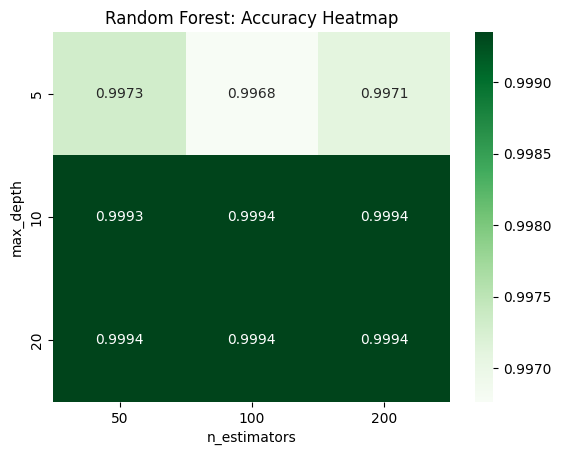

In [22]:
# Define parameter grid
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform GridSearchCV
rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)
rf_grid_search.fit(X_multiclass, y_multiclass)

# Extract best parameters and score
print("Best Random Forest Parameters:", rf_grid_search.best_params_)
print("Best Random Forest Accuracy:", rf_grid_search.best_score_)

# Visualization: Heatmap of max_depth and n_estimators
results_rf = pd.DataFrame(rf_grid_search.cv_results_)
heatmap_data_rf = results_rf.pivot_table(
    index='param_max_depth', columns='param_n_estimators', values='mean_test_score'
)
sns.heatmap(heatmap_data_rf, annot=True, fmt=".4f", cmap="Greens")
plt.title("Random Forest: Accuracy Heatmap")
plt.xlabel("n_estimators")
plt.ylabel("max_depth")
plt.show()

**Random Forest Heatmap Summary**

The Random Forest model shows excellent performance, with accuracy ranging from 0.9971 to 0.9994 depending on the parameter settings. Unlike Gradient Boosting, Random Forest demonstrates slight sensitivity to tree depth (`max_depth`). When `max_depth` is limited to 5, the model achieves a slightly lower accuracy of around 0.9971, suggesting that shallow trees are insufficient to fully capture the dataset’s complexity. However, as `max_depth` increases to 10 or 20, the accuracy improves to 0.9994, indicating that deeper trees are better suited for this task.

The number of trees (`n_estimators`) has a minimal impact on performance. Accuracy stabilizes quickly with as few as 50 trees, and further increases to 100 or 200 provide diminishing returns. This finding highlights the efficiency of Random Forest, as it achieves near-optimal performance with a relatively small number of trees.

Overall, Random Forest proves to be a reliable and efficient choice for multiclass classification. Its slight sensitivity to tree depth allows for meaningful parameter tuning, while its robustness ensures consistent high performance once optimal parameters are selected.

**Best Model for Multiclass Classification**

Based on the analysis, **Gradient Boosting** is identified as the most suitable model for multiclass classification in this project. Gradient Boosting achieved **perfect accuracy** (**1.0000**) on both the training and test datasets, accurately classifying all samples into their respective categories (`Low`, `Moderate`, and `High`). Its performance metrics, including precision, recall, and F1-scores, were consistently perfect across all classes, with no misclassifications observed in the confusion matrix. This level of performance highlights its ability to effectively handle the dataset’s complexity and reliably distinguish between the three health status categories.

After hyperparameter tuning, Gradient Boosting maintained its robust performance, achieving a slightly adjusted accuracy of **0.9992** with parameters such as `learning_rate = 0.01` and `max_depth = 3`. These optimizations introduced regularization, reducing the risk of overfitting while ensuring high generalization to unseen data. Furthermore, Gradient Boosting demonstrated its capability to effectively integrate additional features, such as `Gender` and `Hypertension_Prevalence`, without compromising its performance. This adaptability underscores its suitability for handling complex feature interactions in this dataset.

In comparison, **Random Forest** also performed exceptionally well, achieving an accuracy of **0.9994**; however, it exhibited minor misclassifications, such as a few `Low` risk samples being misclassified as `High`. **Logistic Regression**, while effective, demonstrated a lower accuracy of **0.9547** and struggled more with distinguishing between classes, particularly for High risk samples. These results position Gradient Boosting as the superior model for this task.

Moreover, Gradient Boosting offers the advantage of interpretability through feature importance analysis, enabling insights into how different features contribute to predictions. This aligns with the project’s objective of making informed decisions based on the model’s outputs. Overall, Gradient Boosting’s perfect accuracy, robustness to hyperparameter tuning, and ability to leverage additional features make it the most reliable and suitable model for multiclass classification in this project.

## Regression

### Define Features and Target for Regression

In this regression analysis, the dependent variable (`y_reg`) is chosen as **`Diabetes_Crude`**, representing the crude prevalence of diabetes. This continuous health indicator is a key metric for understanding the impact of various health factors on diabetes rates. By predicting **`Diabetes_Crude`**, the model aims to explore the relationship between diabetes prevalence and independent variables such as BMI, Hypertension Control, Hypertension Prevalence, and Gender. These predictors are selected based on their established relevance in medical and public health studies: BMI is strongly linked to diabetes risk, hypertension control and prevalence often co-occur with diabetes, and gender differences may influence metabolic mechanisms associated with diabetes. Using `Diabetes_Crude` as the target variable allows the regression model to quantify these relationships, providing actionable insights for health professionals and policymakers to develop early intervention strategies. This choice also leverages the continuous nature of the variable, enabling precise predictions and a deeper understanding of how specific health factors influence diabetes prevalence.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Define features and target
X_reg = who_data_preprocessed[['BMI', 'Hypertension_Control', 'Hypertension_Prevalence', 'Gender']]
y_reg = who_data_preprocessed['Diabetes_Crude']

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)


### Model Selection

#### Linear Regression Model

In [24]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_reg, y_train_reg)

# Predictions
y_pred_lr = lr_model.predict(X_test_reg)

# Evaluation Metrics
print("Linear Regression Metrics:")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_lr))
print("MSE:", mean_squared_error(y_test_reg, y_pred_lr))
print("R²:", r2_score(y_test_reg, y_pred_lr))


Linear Regression Metrics:
MAE: 0.5831167917580244
MSE: 0.5707207051160668
R²: 0.43839855601870403


**Linear Regression Model**

The Linear Regression model was trained and evaluated to predict the crude diabetes prevalence (`Diabetes_Crude`) using the selected features (`BMI`, `Hypertension_Control`, `Hypertension_Prevalence`, and `Gender`). The model's performance metrics show moderate predictive capability with an **R² score of 0.438**, indicating that approximately 43.8% of the variance in diabetes prevalence can be explained by the predictors. The Mean Absolute Error (MAE) and Mean Squared Error (MSE) values are **0.583** and **0.571**, respectively, suggesting some degree of residual error in predictions. The residual plot and the "Predictions vs. True Values" plot further indicate that while the model captures some patterns, there is room for improvement.

#### Random Forest Regressor

In [25]:
# Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42, n_estimators=100, max_depth=10)
rf_model.fit(X_train_reg, y_train_reg)

# Predictions
y_pred_rf = rf_model.predict(X_test_reg)

# Evaluation Metrics
print("Random Forest Regression Metrics:")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_rf))
print("MSE:", mean_squared_error(y_test_reg, y_pred_rf))
print("R²:", r2_score(y_test_reg, y_pred_rf))


Random Forest Regression Metrics:
MAE: 0.3742803485759234
MSE: 0.2562936692848403
R²: 0.747801519266137


**Random Forest Regression Model**

Random Forest Regression achieved better performance compared to Linear Regression, with an **R² score of 0.748**, explaining about 74.8% of the variance in the target variable. The MAE and MSE values were **0.374** and **0.256**, respectively, reflecting significantly reduced error levels. The feature importance plot reveals that `BMI` is the dominant predictor, followed by `Hypertension_Control` and `Hypertension_Prevalence`. This result highlights the capability of Random Forest to handle non-linear relationships and capture complex patterns in the data.

#### Gradient Boosting Regressor

In [26]:
# Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(random_state=42, learning_rate=0.1, n_estimators=100, max_depth=3)
gb_model.fit(X_train_reg, y_train_reg)

# Predictions
y_pred_gb = gb_model.predict(X_test_reg)

# Evaluation Metrics
print("Gradient Boosting Regression Metrics:")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_gb))
print("MSE:", mean_squared_error(y_test_reg, y_pred_gb))
print("R²:", r2_score(y_test_reg, y_pred_gb))


Gradient Boosting Regression Metrics:
MAE: 0.448969894409094
MSE: 0.3519557199673348
R²: 0.6536680047188156


**Gradient Boosting Regression Model**

Gradient Boosting Regression performed better than Linear Regression but fell short of the Random Forest model. It achieved an **R² score of 0.654**, explaining 65.4% of the variance. The MAE and MSE values were **0.449** and **0.352**, respectively. While it effectively captures non-linear relationships, the model was slightly less accurate than Random Forest in this case. Feature importance analysis again confirmed `BMI` as the most influential variable, followed by other health indicators.

#### Feature Importance Analysis

For non-linear models like Random Forest and Gradient Boosting, extract and visualize feature importance:

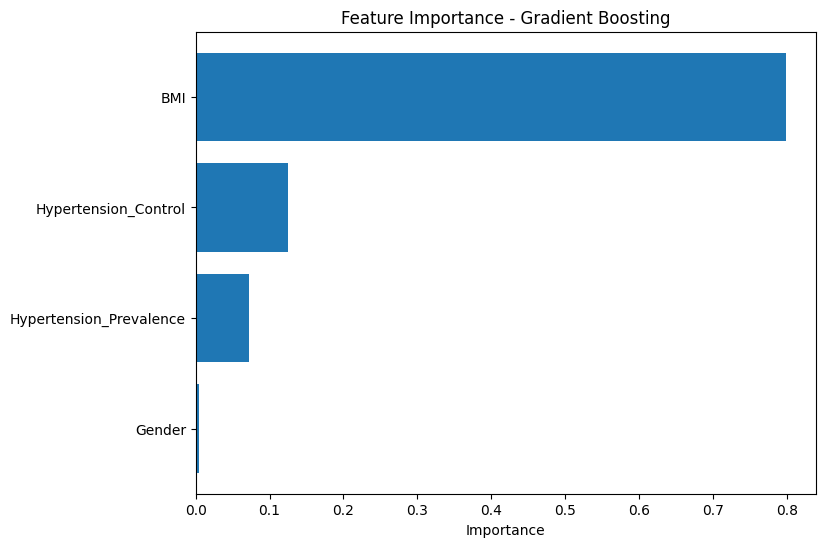

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Feature Importance from Gradient Boosting
importance = gb_model.feature_importances_
indices = np.argsort(importance)

# Plot
plt.figure(figsize=(8, 6))
plt.title("Feature Importance - Gradient Boosting")
plt.barh(range(len(indices)), importance[indices], align="center")
plt.yticks(range(len(indices)), [X_reg.columns[i] for i in indices])
plt.xlabel("Importance")
plt.show()


**Feature Importance**: Gradient Boosting and Random Forest consistently ranked `BMI` as the most critical factor influencing diabetes prevalence. The importance of `Hypertension_Control` and `Hypertension_Prevalence` suggests a strong link between blood pressure management and diabetes outcomes.

## Visualizations

### Scatter Plot of Predictions vs. True Values

/tmp/ipykernel_42798/1935510651.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'k--', color='red')


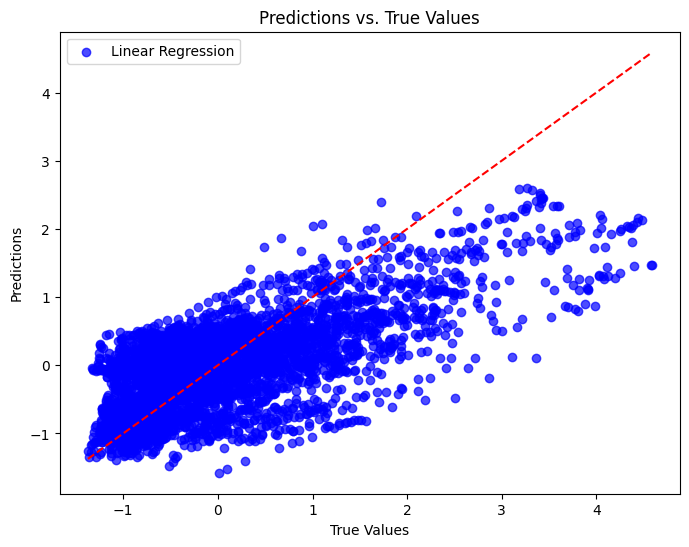

In [28]:
import matplotlib.pyplot as plt

# Assuming y_pred_lr is from Linear Regression predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_lr, alpha=0.7, color='blue', label='Linear Regression')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'k--', color='red')
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("Predictions vs. True Values")
plt.legend()
plt.show()


**Prediction vs. True Values Plot**: The Random Forest model showed the closest alignment between predicted and true values, followed by Gradient Boosting, while Linear Regression exhibited greater dispersion.

### Residual Plot

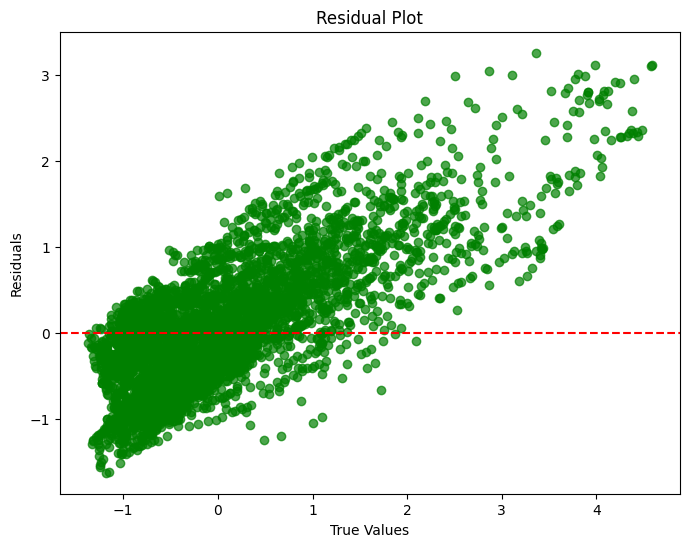

In [29]:
# Residuals for Linear Regression
residuals = y_test_reg - y_pred_lr
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, residuals, alpha=0.7, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("True Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


**Residual Plot**: The residual plot highlights deviations from the regression line, showcasing the models' ability to minimize prediction errors. Random Forest showed the smallest residuals, indicating its superior performance.

**Conclusion**

For predicting diabetes prevalence, Random Forest demonstrated the best overall performance with the highest R² and lowest errors. Its ability to model complex, non-linear relationships makes it the preferred choice for this regression task. Gradient Boosting also performed well and can serve as an alternative where interpretability of boosting steps is a priority. Linear Regression, while simpler, was less effective due to its linear assumptions and inability to capture complex interactions among features.